# **Setup & imports**

In [28]:
# Setup & imports
# Run this cell first. If PuLP is missing, uncomment pip install line below.

# !pip install pulp plotly

import os, time, math, random, json
from collections import namedtuple, defaultdict
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.simple_paths import shortest_simple_paths
from matplotlib import animation as mpl_animation
from IPython.display import HTML, display

# Optional (Plotly Sankey)
try:
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
except Exception:
    PLOTLY_AVAILABLE = False

# Solver (PuLP)
try:
    import pulp
    PULP_AVAILABLE = True
except Exception:
    pulp = None
    PULP_AVAILABLE = False

# Reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Data types
Flow = namedtuple("Flow", ["id","src","dst","src_port","dst_port","protocol",
                           "start_ts","end_ts","pkts","bytes","avg_iat_s","duration_s","bandwidth_mbps","flow_type"])

class VNF:
    def __init__(self,name,cpu_per_mbps,processing_ms,stateful,supports):
        self.name = name
        self.cpu_per_mbps = cpu_per_mbps
        self.processing_ms = processing_ms
        self.stateful = stateful
        self.supports = supports


# **Load Wireshark CSV and aggregate into flows**

In [29]:
# Load Wireshark CSV and aggregate into flows
# Set CSV_PATH to your uploaded CSV. If None, this cell will synthesize demo packets.
CSV_PATH = "/content/packets.csv"  #
TIME_GAP_THRESHOLD_S = 60.0  # split flows if gap > threshold

def load_wireshark_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    # map common columns
    col_map = {}
    lookup = {'time':['Time','time','frame.time'],'src':['Source','source','src'],'dst':['Destination','destination','dst'],
              'protocol':['Protocol','protocol'],'length':['Length','len']}
    for k, cand in lookup.items():
        for c in cand:
            if c in df.columns:
                col_map[k] = c; break
    for req in ['time','src','dst','protocol','length']:
        if req not in col_map:
            raise ValueError(f"CSV missing column for {req}. Found: {df.columns.tolist()}")
    df = df.rename(columns={col_map[k]:k for k in col_map})

    # Handle missing port columns by creating empty series
    if 'Source Port' in df.columns:
        df['src_port'] = df['Source Port'].fillna('').astype(str)
    else:
        df['src_port'] = pd.Series('', index=df.index, dtype=str)

    if 'Destination Port' in df.columns:
        df['dst_port'] = df['Destination Port'].fillna('').astype(str)
    else:
        df['dst_port'] = pd.Series('', index=df.index, dtype=str)

    df['length'] = pd.to_numeric(df['length'], errors='coerce').fillna(0).astype(int)
    try:
        df['time'] = pd.to_datetime(df['time'])
    except Exception:
        df['time'] = pd.to_numeric(df['time'], errors='coerce')
    return df

def classify_protocol(proto_field: str) -> str:
    try:
        proto_num = int(proto_field)
        if proto_num == 6: return 'TCP'
        if proto_num == 17: return 'Non-TCP'
    except:
        pass
    p = str(proto_field).upper()
    tcp_like = ['TCP','HTTP','TLS','TLSV1.2','TLSV1.3','XMPP','SSH','FTP']
    non_tcp_like = ['UDP','QUIC','SSDP','NBNS','RTP','SCTP','DNS']
    if any(tok in p for tok in tcp_like): return 'TCP'
    if any(tok in p for tok in non_tcp_like): return 'Non-TCP'
    return 'Non-TCP'

def aggregate_flows(df: pd.DataFrame, time_gap_threshold_s: float = 60.0) -> List[Flow]:
    df['protocol'] = df['protocol'].astype(str).str.upper().str.strip()
    df['src_port'] = df['src_port'].fillna('').astype(str)
    df['dst_port'] = df['dst_port'].fillna('').astype(str)
    df['five_tuple'] = df['src'].astype(str) + '|' + df['dst'].astype(str) + '|' + df['src_port'] + '|' + df['dst_port'] + '|' + df['protocol']
    flows = []; fid=0
    for key, group in df.groupby('five_tuple'):
        group = group.sort_values('time')
        times = group['time'].tolist(); lengths = group['length'].tolist()
        src = group['src'].iat[0]; dst = group['dst'].iat[0]; proto = group['protocol'].iat[0]
        cur_pkts=0; cur_bytes=0; start_ts=None; last_ts=None; iat=[]
        for t, ln in zip(times, lengths):
            ts = t.timestamp() if hasattr(t, 'timestamp') else float(t)
            if start_ts is None:
                start_ts=ts; last_ts=ts; cur_pkts=1; cur_bytes=int(ln); iat=[]
            else:
                gap = ts - last_ts
                if gap > time_gap_threshold_s:
                    end_ts = last_ts; dur = max(1e-6, end_ts-start_ts)
                    bw_mbps = (cur_bytes*8.0)/(dur*1e6)
                    ftype = classify_protocol(proto)
                    flows.append(Flow(fid, src, dst, group['src_port'].iat[0], group['dst_port'].iat[0], proto, start_ts, end_ts, cur_pkts, cur_bytes, np.mean(iat) if iat else 0.0, dur, bw_mbps, ftype))
                    fid+=1
                    start_ts=ts; last_ts=ts; cur_pkts=1; cur_bytes=int(ln); iat=[]
                else:
                    iat.append(gap); cur_pkts+=1; cur_bytes+=int(ln); last_ts=ts
        if start_ts is not None:
            end_ts = last_ts; dur=max(1e-6,end_ts-start_ts)
            bw_mbps=(cur_bytes*8.0)/(dur*1e6)
            ftype = classify_protocol(proto)
            flows.append(Flow(fid, src, dst, group['src_port'].iat[0], group['dst_port'].iat[0], proto, start_ts, end_ts, cur_pkts, cur_bytes, np.mean(iat) if iat else 0.0, dur, bw_mbps, ftype))
            fid+=1
    return flows

# Load or synthesize
if CSV_PATH and os.path.exists(CSV_PATH):
    df_raw = load_wireshark_csv(CSV_PATH)
    print("Loaded CSV:", CSV_PATH)
else:
    print("CSV not found. Generating synthetic packet-level data for demo...")
    rows=[]; t0=time.time()
    for i in range(300):
        ts = t0 + i*0.03 + random.random()*0.005
        src=f"10.0.0.{random.randint(1,8)}"; dst=f"10.0.1.{random.randint(1,8)}"
        proto = random.choice(['TCP','UDP','QUIC','HTTP','TLSv1.2'])
        rows.append({'Time':ts,'Source':src,'Destination':dst,'Protocol':proto,'Length':random.randint(60,1400),'Source Port':random.randint(1024,65535),'Destination Port':random.randint(1024,65535)})
    df_raw = pd.DataFrame(rows)
    df_raw.to_csv('/content/demo_packets.csv', index=False)
    CSV_PATH = '/content/demo_packets.csv'
    print("Synthetic CSV saved to /content/demo_packets.csv")

display(df_raw.head())
flows = aggregate_flows(df_raw, TIME_GAP_THRESHOLD_S)
print(f"Aggregated flows: {len(flows)} (showing first 5)")
for f in flows[:5]:
    print(f)
# Summary
types = defaultdict(int)
for f in flows: types[f.flow_type]+=1
print("Flow types:", dict(types))

Loaded CSV: /content/packets.csv


,No.,time,src,dst,protocol,length,Info,src_port,dst_port
0,1,1970-01-01,192.168.1.9,142.250.82.211,UDP,253,62618 > 3478 Len=211,,
1,2,1970-01-01,192.168.1.8,239.255.255.250,SSDP,164,M-SEARCH * HTTP/1.1,,
2,3,1970-01-01,192.168.1.9,142.250.82.211,UDP,253,62618 > 3478 Len=211,,
3,4,1970-01-01,192.168.1.9,142.250.82.211,UDP,253,62618 > 3478 Len=211,,
4,5,1970-01-01,142.250.82.211,192.168.1.9,RTCP,106,Application specific subtype=13,,


Aggregated flows: 1082 (showing first 5)
Flow(id=0, src='0.0.0.0', dst='224.0.0.1', src_port='', dst_port='', protocol='IGMPV2', start_ts=0.0, end_ts=0.0, pkts=4, bytes=184, avg_iat_s=np.float64(0.0), duration_s=1e-06, bandwidth_mbps=1472.0, flow_type='Non-TCP')
Flow(id=1, src='0.0.0.0', dst='255.255.255.255', src_port='', dst_port='', protocol='DHCP', start_ts=0.0, end_ts=0.0, pkts=2, bytes=688, avg_iat_s=np.float64(0.0), duration_s=1e-06, bandwidth_mbps=5504.0, flow_type='Non-TCP')
Flow(id=2, src='103.151.126.212', dst='192.168.1.9', src_port='', dst_port='', protocol='TCP', start_ts=0.0, end_ts=0.0, pkts=6, bytes=384, avg_iat_s=np.float64(0.0), duration_s=1e-06, bandwidth_mbps=3072.0, flow_type='TCP')
Flow(id=3, src='103.151.126.212', dst='192.168.1.9', src_port='', dst_port='', protocol='TLSV1.2', start_ts=0.0, end_ts=0.0, pkts=1, bytes=78, avg_iat_s=0.0, duration_s=1e-06, bandwidth_mbps=624.0, flow_type='TCP')
Flow(id=4, src='104.104.138.130', dst='192.168.1.9', src_port='', dst_p

/tmp/ipython-input-1994355527.py:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




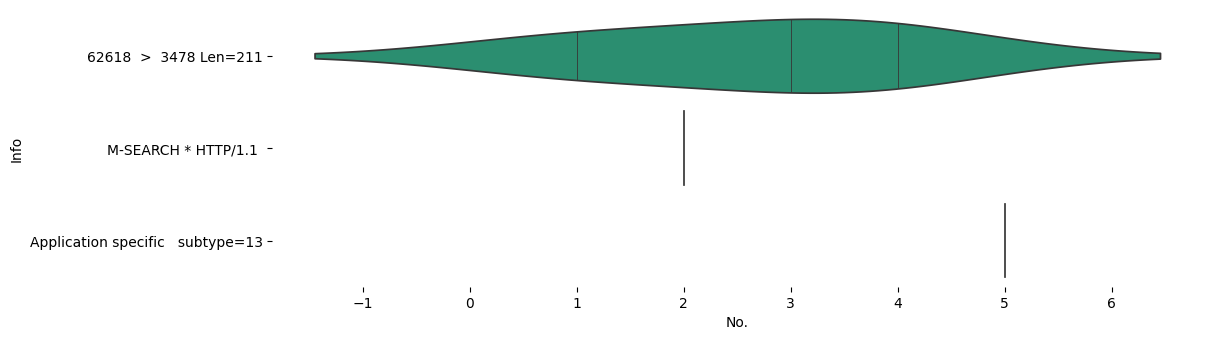

In [30]:
from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_19['Info'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_19, x='No.', y='Info', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

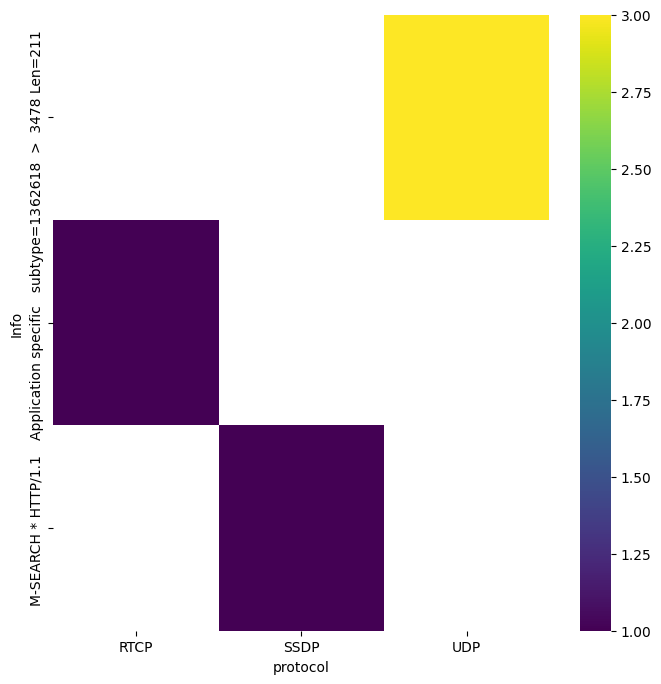

In [31]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['Info'].value_counts()
    for x_label, grp in _df_15.groupby('protocol')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('protocol')
_ = plt.ylabel('Info')

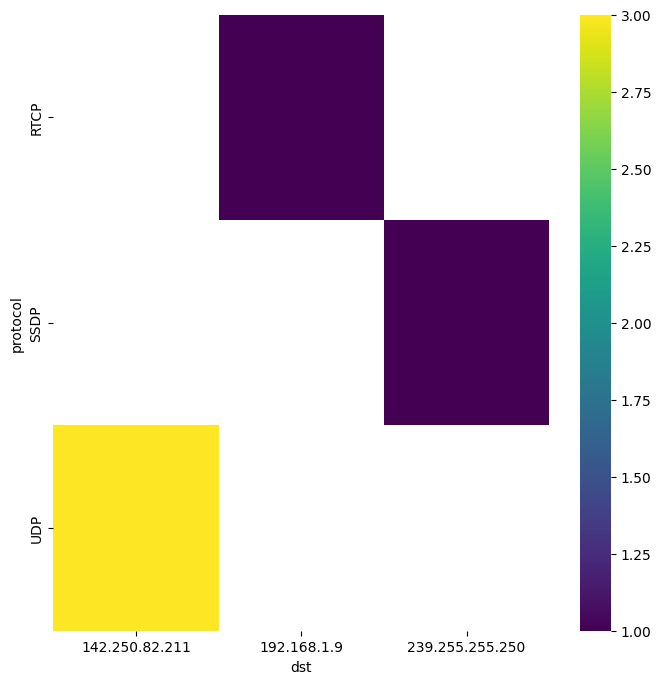

In [32]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
plt.subplots(figsize=(8, 8))
df_2dhist = pd.DataFrame({
    x_label: grp['protocol'].value_counts()
    for x_label, grp in _df_14.groupby('dst')
})
sns.heatmap(df_2dhist, cmap='viridis')
plt.xlabel('dst')
_ = plt.ylabel('protocol')

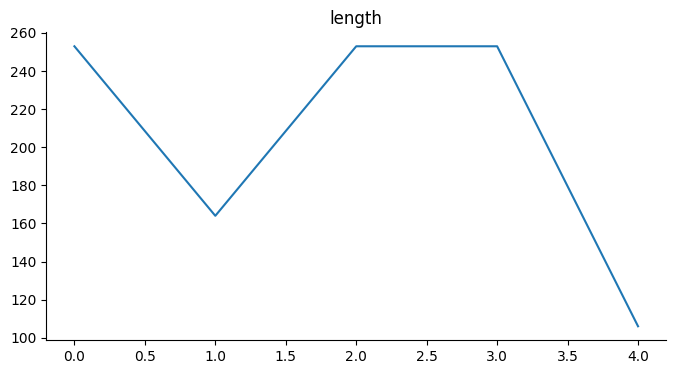

In [33]:
from matplotlib import pyplot as plt
_df_12['length'].plot(kind='line', figsize=(8, 4), title='length')
plt.gca().spines[['top', 'right']].set_visible(False)

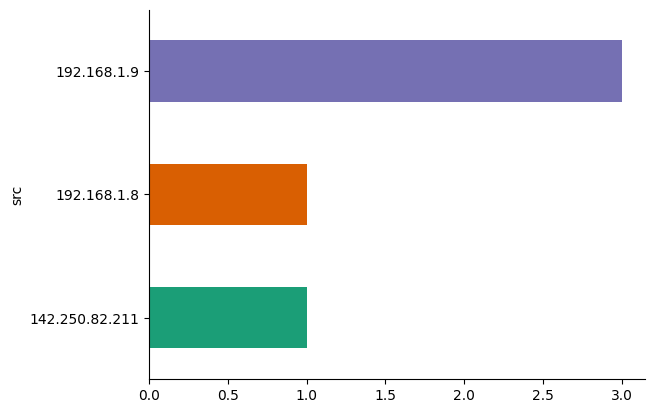

In [34]:
from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('src').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

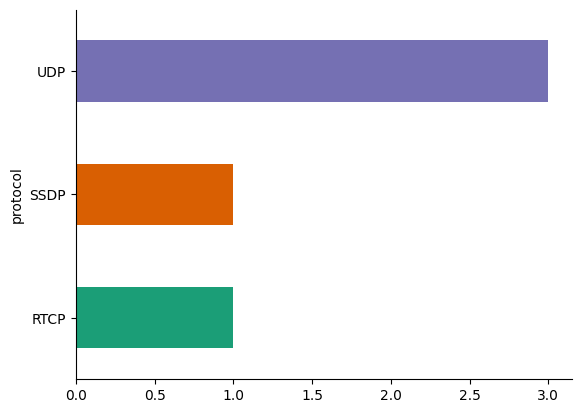

In [35]:
from matplotlib import pyplot as plt
import seaborn as sns
_df_4.groupby('protocol').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

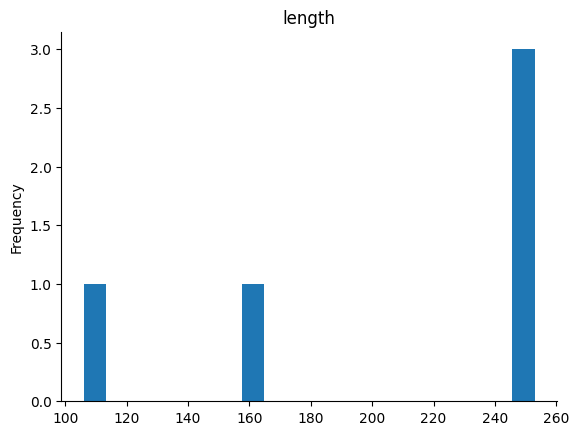

In [36]:
from matplotlib import pyplot as plt
_df_1['length'].plot(kind='hist', bins=20, title='length')
plt.gca().spines[['top', 'right',]].set_visible(False)

# **Topology, VNF definitions, visualization helpers**

Topology nodes and attributes:
n1 {'cpu_capacity': 60.0, 'tcp_acceleration': False}
n2 {'cpu_capacity': 120.0, 'tcp_acceleration': False}
n3 {'cpu_capacity': 60.0, 'tcp_acceleration': True}
n4 {'cpu_capacity': 120.0, 'tcp_acceleration': False}
n5 {'cpu_capacity': 60.0, 'tcp_acceleration': False}
n6 {'cpu_capacity': 120.0, 'tcp_acceleration': True}
n7 {'cpu_capacity': 60.0, 'tcp_acceleration': False}
n8 {'cpu_capacity': 120.0, 'tcp_acceleration': False}


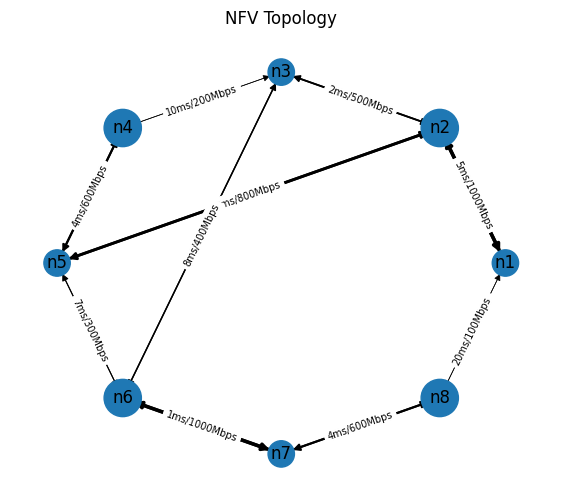

In [37]:
# Topology, VNF definitions, visualization helpers
def build_sample_topology_layout() -> Tuple[nx.DiGraph, Dict[str,Tuple[float,float]]]:
    G = nx.DiGraph(); positions={}
    n_nodes=8
    for i in range(1,n_nodes+1):
        nid=f"n{i}"
        cpu = 120.0 if i%2==0 else 60.0
        tcp_acc = (i%3==0)
        G.add_node(nid, cpu_capacity=cpu, tcp_acceleration=tcp_acc)
        angle = 2*math.pi*(i-1)/n_nodes
        positions[nid] = (math.cos(angle), math.sin(angle))
    base_edges=[('n1','n2',5,1000),('n2','n3',2,500),('n3','n4',10,200),('n4','n5',4,600),('n5','n6',7,300),('n6','n7',1,1000),('n7','n8',4,600),('n8','n1',20,100),('n2','n5',3,800),('n3','n6',8,400)]
    for u,v,lat,bw in base_edges:
        G.add_edge(u,v, latency=lat, bandwidth=bw)
        G.add_edge(v,u, latency=lat, bandwidth=bw)
    return G, positions

def define_vnfs() -> Dict[str,VNF]:
    return {
        'Proxy': VNF('Proxy', cpu_per_mbps=0.05, processing_ms=1.5, stateful=False, supports=['TCP']),
        'Firewall': VNF('Firewall', cpu_per_mbps=0.02, processing_ms=0.8, stateful=False, supports=['TCP','UDP']),
        'NAT': VNF('NAT', cpu_per_mbps=0.01, processing_ms=0.5, stateful=True, supports=['TCP','UDP'])
    }

def visualize_topology(G, pos, title="NFV Topology"):
    plt.figure(figsize=(7,6))
    node_sizes=[G.nodes[n]['cpu_capacity']*6 for n in G.nodes()]
    nx.draw_networkx_nodes(G,pos,node_size=node_sizes)
    nx.draw_networkx_labels(G,pos)
    widths=[max(0.5,G[u][v]['bandwidth']/400.0) for u,v in G.edges()]
    nx.draw_networkx_edges(G,pos,width=widths,arrows=True)
    edge_labels={(u,v):f"{G[u][v]['latency']}ms/{G[u][v]['bandwidth']}Mbps" for u,v in G.edges()}
    nx.draw_networkx_edge_labels(G,pos,edge_labels=edge_labels,font_size=7)
    plt.title(title); plt.axis('off'); plt.show()

# Deterministic IP->node mapping
def map_ip_to_node(ip: str, G: nx.DiGraph) -> str:
    nodes = sorted(list(G.nodes()))
    try:
        last = int(ip.split('.')[-1])
        idx = last % len(nodes)
    except:
        idx = abs(hash(ip)) % len(nodes)
    # ensure dst != src logic handled upstream
    return nodes[idx]

# Build topology + vnfs
G, positions = build_sample_topology_layout()
vnfs = define_vnfs()
print("Topology nodes and attributes:")
for n,attr in G.nodes(data=True): print(n, attr)
visualize_topology(G, positions)


# **Candidate path generation, pruning, SFC mapping (TCP vs Non-TCP)**

In [38]:
# Candidate path generation, pruning, SFC mapping (TCP vs Non-TCP)
def k_shortest_paths_metric(G: nx.DiGraph, source: str, target: str, k: int=6, non_tcp: bool=False) -> List[List[str]]:
    gen = shortest_simple_paths(G, source, target)
    scored=[]
    for p in gen:
        if len(p) <= 1: continue
        if non_tcp:
            score = sum(1.0/max(G[p[i]][p[i+1]]['bandwidth'],1e-6) for i in range(len(p)-1)) + 0.1*(len(p)-1)
        else:
            score = sum(G[p[i]][p[i+1]]['latency'] for i in range(len(p)-1))
        scored.append((list(p), score))
        if len(scored) >= 200: break
    scored.sort(key=lambda x: x[1])
    return [p for p,_ in scored[:k]]

def prune_paths_by_bandwidth(G: nx.DiGraph, paths: List[List[str]], flow_bandwidth_mbps: float) -> List[List[str]]:
    feasible=[]
    for p in paths:
        ok=True
        for i in range(len(p)-1):
            bw = G[p[i]][p[i+1]]['bandwidth']
            if bw + 1e-9 < flow_bandwidth_mbps:
                ok=False; break
        if ok: feasible.append(p)
    return feasible

def precompute_path_attributes(G: nx.DiGraph, paths: List[List[str]]) -> List[Dict[str,Any]]:
    pattrs=[]
    for p in paths:
        if len(p)<=1: continue
        latency = sum(G[p[i]][p[i+1]]['latency'] for i in range(len(p)-1))
        hops = len(p)-1
        bottleneck = min(G[p[i]][p[i+1]]['bandwidth'] for i in range(len(p)-1))
        pattrs.append({'path':p,'latency':latency,'hops':hops,'bottleneck_bw':bottleneck})
    return pattrs

def ensure_candidate_paths(G, flow, k=6):
    src_node = map_ip_to_node(flow.src, G)
    dst_node = map_ip_to_node(flow.dst, G)
    # ensure src != dst deterministically
    if src_node == dst_node:
        nodes = sorted(list(G.nodes()))
        dst_node = nodes[(nodes.index(src_node)+1) % len(nodes)]
    paths = k_shortest_paths_metric(G, src_node, dst_node, k=k, non_tcp=(flow.flow_type=='Non-TCP'))
    feasible = prune_paths_by_bandwidth(G, paths, flow.bandwidth_mbps)
    if not feasible:
        # relaxed fallback (50% demand)
        feasible = prune_paths_by_bandwidth(G, paths, max(0.0001, 0.5*flow.bandwidth_mbps))
    return precompute_path_attributes(G, feasible)

def map_sfc_for_flows(flows: List[Flow]) -> Dict[int,List[str]]:
    sfc_map={}
    for f in flows:
        sfc_map[f.id] = ['Proxy','Firewall','NAT'] if f.flow_type=='TCP' else ['Firewall','NAT']
    return sfc_map

# Build candidate paths for first N flows (demo)
N_build = min(40, len(flows))
flow_path_candidates = {}
for f in flows[:N_build]:
    flow_path_candidates[f.id] = ensure_candidate_paths(G, f, k=6)

# show any flows without candidates
no_cands = [fid for fid,plist in flow_path_candidates.items() if not plist]
print("Flows with no/relaxed candidates:", no_cands[:10])
sfc_map = map_sfc_for_flows(flows)
print("Example SFC map (first 6 flows):")
for f in flows[:6]:
    print(f"Flow {f.id}: {f.flow_type}, SFC={sfc_map[f.id]}, candidates={len(flow_path_candidates.get(f.id,[]))}")


Flows with no/relaxed candidates: [1, 2, 4, 5, 6, 8, 9, 10, 12, 13]
Example SFC map (first 6 flows):
Flow 0: Non-TCP, SFC=['Firewall', 'NAT'], candidates=1
Flow 1: Non-TCP, SFC=['Firewall', 'NAT'], candidates=0
Flow 2: TCP, SFC=['Proxy', 'Firewall', 'NAT'], candidates=0
Flow 3: TCP, SFC=['Proxy', 'Firewall', 'NAT'], candidates=1
Flow 4: TCP, SFC=['Proxy', 'Firewall', 'NAT'], candidates=0
Flow 5: TCP, SFC=['Proxy', 'Firewall', 'NAT'], candidates=0


# **Placement algorithms**

In [39]:
# Placement algorithms
# Greedy placer
def greedy_placer(G, flows, sfc_map, vnfs, flow_path_candidates):
    placement={}; node_cpu_remaining={n:G.nodes[n]['cpu_capacity'] for n in G.nodes()}
    for f in flows:
        assigned=None
        for p_attr in flow_path_candidates.get(f.id, []):
            p = p_attr['path']
            assignment={}; feasible=True
            for i,v in enumerate(sfc_map[f.id]):
                # choose first node along path with CPU (TCP prefer tcp_acceleration)
                candidates = p.copy()
                if f.flow_type=='TCP':
                    candidates.sort(key=lambda n:(not G.nodes[n]['tcp_acceleration'], p.index(n)))
                else:
                    candidates.sort(key=lambda n: p.index(n))
                chosen=None
                for n in candidates:
                    cpu_need = vnfs[v].cpu_per_mbps * max(0.001, f.bandwidth_mbps)
                    if node_cpu_remaining[n] >= cpu_need:
                        chosen=n; node_cpu_remaining[n]-=cpu_need; assignment[i]=n; break
                if chosen is None:
                    feasible=False; break
            if feasible:
                assigned=assignment; break
        placement[f.id]=assigned
    return placement

# DP-based placer following A/L/P/T idea (per flow across candidate paths)
def dp_place_on_path(A_G, flow: Flow, sfc: List[str], vnfs: Dict[str,VNF], path: List[str], G: nx.DiGraph, cpu_state: Dict[str,float], flow_bw: float):
    # A_G: unused here (kept for parity); we implement A/L/P/T core
    m = len(path); k = len(sfc)
    INF=1e12
    # L[node_idx][i] = minimal latency to place first i VNFs with i-th at node path[node_idx]
    L = [[INF]*m for _ in range(k+1)]
    Prev = [[-1]*m for _ in range(k+1)]
    # T snapshots: store cpu_remain per node if we reached node j for i VNFs
    T_snap = [[None]*m for _ in range(k+1)]
    # initialize for first VNF
    for j in range(m):
        node = path[j]
        vname = sfc[0]
        # check protocol support and CPU
        if flow.flow_type in ['TCP','Non-TCP'] and vname in vnfs:
            cpu_need = vnfs[vname].cpu_per_mbps * max(0.001, flow_bw)
            if vnfs[vname].supports and (flow.flow_type=='TCP' and 'TCP' in vnfs[vname].supports or flow.flow_type=='Non-TCP' and any(True for _ in [1])):
                if cpu_state[node] >= cpu_need:
                    # latency from src to this node along subpath
                    src_node = map_ip_to_node(flow.src, G)
                    try:
                        lat = nx.shortest_path_length(G, src_node, node, weight='latency')
                    except:
                        lat = INF
                    if lat < INF:
                        L[1][j] = lat + vnfs[vname].processing_ms
                        # snapshot
                        snap = cpu_state.copy()
                        snap[node] -= cpu_need
                        T_snap[1][j] = snap
    # recurrence
    for i in range(2, k+1):
        vname = sfc[i-1]
        for j in range(m):
            node_j = path[j]
            cpu_need_j = vnfs[vname].cpu_per_mbps * max(0.001, flow_bw)
            for p in range(j):
                if L[i-1][p] >= INF: continue
                # check snapshot T_snap[i-1][p] for bandwidth feasibility on subpath between path[p] and path[j]
                snap = T_snap[i-1][p]
                if snap is None: continue
                # path segment latency
                try:
                    seg_lat = nx.shortest_path_length(G, path[p], node_j, weight='latency')
                except:
                    continue
                # check cpu available in snapshot
                if snap[node_j] < cpu_need_j: continue
                cand = L[i-1][p] + seg_lat + vnfs[vname].processing_ms
                if cand < L[i][j]:
                    L[i][j] = cand
                    Prev[i][j] = p
                    snap2 = snap.copy(); snap2[node_j] -= cpu_need_j
                    T_snap[i][j] = snap2
    # finalize: add latency to dst
    best=INF; best_idx=-1
    for j in range(m):
        if L[k][j] < INF:
            try:
                dst_node = map_ip_to_node(flow.dst, G)
                tail = nx.shortest_path_length(G, path[j], dst_node, weight='latency')
            except:
                tail = INF
            tot = L[k][j] + tail
            if tot < best:
                best=tot; best_idx=j
    if best_idx==-1:
        return None, None
    # reconstruct assignment
    assign={}
    idx = best_idx
    for i in range(k,0,-1):
        assign[i-1] = path[idx]
        idx = Prev[i][idx] if Prev[i][idx] is not None else -1
    return assign, best

def dp_placer_all(G, flows, sfc_map, vnfs, flow_path_candidates):
    placement={}; cost_map={}
    # initial cpu state (copy)
    base_cpu = {n:G.nodes[n]['cpu_capacity'] for n in G.nodes()}
    for f in flows:
        best=None; best_cost=None
        candidates = flow_path_candidates.get(f.id, [])
        for p_attr in candidates:
            path = p_attr['path']
            assign, cost = dp_place_on_path(None, f, sfc_map[f.id], vnfs, path, G, base_cpu, f.bandwidth_mbps)
            if assign is not None:
                # advance cpu state for accepted assignment temporarily (we don't reserve globally here)
                best=assign; best_cost=cost; break
        placement[f.id]=best; cost_map[f.id]=best_cost
    return placement, cost_map

# MILP (PuLP) with flow acceptance variable y_f
def build_and_solve_milp(G, flows, sfc_map, flow_path_candidates, vnfs, time_limit_s=60):
    if not PULP_AVAILABLE:
        print("PuLP not available. Skipping MILP.")
        return None, None, None, None
    prob = pulp.LpProblem("SFC_Placement", pulp.LpMinimize)
    nodes = list(G.nodes()); V = list(vnfs.keys())
    # variables
    x = pulp.LpVariable.dicts('x', (nodes, V), cat='Binary')  # VNF placement
    w = {}  # w[f,p]
    y = {}  # accept flow
    P = {f.id: [tuple(p['path']) for p in flow_path_candidates.get(f.id, [])] for f in flows}
    for f in flows:
        y[f.id] = pulp.LpVariable(f"y_{f.id}", cat='Binary')
        for p in P[f.id]:
            w[(f.id,p)] = pulp.LpVariable(f"w_{f.id}_{'_'.join(p)}", cat='Binary')
    # z: where flow's i-th VNF placed
    z = {}
    for f in flows:
        sfc = sfc_map[f.id]
        for i,v in enumerate(sfc):
            for n in nodes:
                z[(f.id,i,n)] = pulp.LpVariable(f"z_{f.id}_{i}_{n}", cat='Binary')
    # objective: latency via chosen path + small x cost + penalty for not placing flows
    alpha_tcp=1.0; alpha_nontcp=0.5; beta_place=0.001; big_pen=1000
    obj=[]
    path_latency={}
    for f in flows:
        path_latency[f.id]={}
        for p in P[f.id]:
            lat = sum(G[p[i]][p[i+1]]['latency'] for i in range(len(p)-1)) if len(p)>1 else 0.0
            path_latency[f.id][p]=lat
            alpha = alpha_tcp if f.flow_type=='TCP' else alpha_nontcp
            obj.append(alpha * lat * w[(f.id,p)])
        obj.append(big_pen * (1 - y[f.id]))  # penalize unaccepted flows
    for n in nodes:
        for v in V:
            obj.append(beta_place * x[n][v])
    prob += pulp.lpSum(obj)
    # constraints
    for f in flows:
        # path selection sum equals y_f
        if len(P[f.id])>0:
            prob += pulp.lpSum([w[(f.id,p)] for p in P[f.id]]) == y[f.id]
        else:
            prob += y[f.id] == 0
        # each VNF in SFC must be placed at exactly one node if y_f==1
        sfc = sfc_map[f.id]
        for i,v in enumerate(sfc):
            prob += pulp.lpSum([z[(f.id,i,n)] for n in nodes]) == y[f.id]
            for n in nodes:
                prob += z[(f.id,i,n)] <= x[n][v]
    # node CPU cap
    for n in nodes:
        prob += pulp.lpSum([vnfs[sfc_map[f.id][i]].cpu_per_mbps * f.bandwidth_mbps * z[(f.id,i,n)]
                             for f in flows for i in range(len(sfc_map[f.id])) ]) <= G.nodes[n]['cpu_capacity']
    # link capacity from chosen paths
    for u,v,edata in G.edges(data=True):
        cap = edata['bandwidth']
        usage=[]
        for f in flows:
            for p in P[f.id]:
                path_nodes = list(p)
                for i in range(len(path_nodes)-1):
                    if path_nodes[i]==u and path_nodes[i+1]==v:
                        usage.append(f.bandwidth_mbps * w[(f.id,p)])
                        break
        if usage:
            prob += pulp.lpSum(usage) <= cap
    solver = pulp.PULP_CBC_CMD(timeLimit=time_limit_s, msg=False)
    prob.solve(solver)
    # extract
    x_sol={(n,v): int(pulp.value(x[n][v])) for n in nodes for v in V}
    z_sol={(f.id,i,n): int(pulp.value(z[(f.id,i,n)])) for f in flows for i in range(len(sfc_map[f.id])) for n in nodes}
    w_sol={(f.id,p): int(pulp.value(w[(f.id,p)])) for f in flows for p in P[f.id]}
    y_sol={f.id:int(pulp.value(y[f.id])) for f in flows}
    stats={'status':pulp.LpStatus[prob.status] if hasattr(pulp,'LpStatus') else None, 'objective':pulp.value(prob.objective)}
    return x_sol, z_sol, w_sol, y_sol, stats


# **Packet-level simulation, animation, evaluation & demo end-to-end run**

In [40]:
# Packet-level simulation, animation, evaluation & demo end-to-end run
def build_packet_event_list(G, flows, placement, sfc_map, flow_path_candidates, positions, max_packets_per_flow=6, duration_s=6.0):
    events=[]
    for f in flows:
        assign = placement.get(f.id)
        if assign is None: continue
        # pick candidate path that includes assigned nodes in order
        candidates = flow_path_candidates.get(f.id, [])
        chosen_path=None
        for p_attr in candidates:
            p = p_attr['path']
            try:
                idxs = [p.index(assign[i]) for i in range(len(assign))]
                if idxs == sorted(idxs):
                    chosen_path = p; break
            except Exception:
                continue
        if chosen_path is None:
            try:
                chosen_path = nx.shortest_path(G, map_ip_to_node(f.src, G), map_ip_to_node(f.dst, G), weight='latency')
            except:
                continue
        pkt_count = min(max_packets_per_flow, max(1, int(max(1, f.pkts/10))))
        times = np.linspace(0.1, duration_s-0.1, pkt_count)
        for pkt_idx, t0 in enumerate(times):
            for hop in range(len(chosen_path)-1):
                u = chosen_path[hop]; v = chosen_path[hop+1]
                events.append({'time': float(t0 + pkt_idx*0.001 + hop*0.02), 'flow': f.id, 'u':u, 'v':v, 'type':f.flow_type})
    events_sorted = sorted(events, key=lambda e:e['time'])
    return events_sorted

def animate_packet_events(G, positions, events, interval_ms=120, title="Packet Movement (red=TCP, blue=Non-TCP)"):
    fig, ax = plt.subplots(figsize=(8,6))
    nx.draw_networkx_nodes(G, positions, node_size=[G.nodes[n]['cpu_capacity']*6 for n in G.nodes()], ax=ax)
    nx.draw_networkx_labels(G, positions, ax=ax); nx.draw_networkx_edges(G, positions, ax=ax)
    scat = ax.scatter([], [], s=120, zorder=5)
    times = sorted(list({round(e['time'],3) for e in events}))
    if not times:
        print("No events to animate.")
        return None
    def update(i):
        t = times[i]; current=[e for e in events if abs(round(e['time'],3)-t) < 1e-6]
        xs=[]; ys=[]; colors=[]
        for ev in current:
            u=ev['u']; v=ev['v']; x1,y1 = positions[u]; x2,y2 = positions[v]
            xs.append((x1+x2)/2.0); ys.append((y1+y2)/2.0)
            colors.append('red' if ev['type']=='TCP' else 'blue')
        if xs:
            scat.set_offsets(list(zip(xs,ys))); scat.set_color(colors)
        else:
            scat.set_offsets([])
        ax.set_title(f"{title} | t={t:.3f}s | events={len(current)}")
        return scat,
    ani = mpl_animation.FuncAnimation(fig, update, frames=len(times), interval=interval_ms, blit=False, repeat=False)
    plt.close(fig)
    return HTML(ani.to_jshtml())

def evaluate_placement(G, flows, placement, sfc_map, flow_path_candidates):
    latencies=[]; accepted=0; cpu_usage={n:0.0 for n in G.nodes()}
    for f in flows:
        assign = placement.get(f.id)
        if assign is None: continue
        accepted+=1
        # choose path as before
        chosen=None
        for p_attr in flow_path_candidates.get(f.id,[]):
            p = p_attr['path']
            try:
                idxs=[p.index(assign[i]) for i in range(len(assign))]
                if idxs==sorted(idxs): chosen=p; break
            except:
                continue
        if chosen is None:
            try:
                chosen = nx.shortest_path(G, map_ip_to_node(f.src,G), map_ip_to_node(f.dst,G), weight='latency')
            except:
                continue
        total_lat = sum(G[chosen[i]][chosen[i+1]]['latency'] for i in range(len(chosen)-1))
        latencies.append(total_lat)
        for i,v in enumerate(sfc_map[f.id]):
            cpu_usage[assign[i]] += vnfs[v].cpu_per_mbps * f.bandwidth_mbps
    metrics = {'accepted':accepted, 'total':len(flows), 'mean_latency':float(np.mean(latencies)) if latencies else None, 'p95_latency':float(np.percentile(latencies,95)) if latencies else None, 'cpu_usage':cpu_usage}
    return metrics



# **End to End Run**

Greedy metrics: {'accepted': 7, 'total': 20, 'mean_latency': 5.0, 'p95_latency': 10.7, 'cpu_usage': {'n1': 44.160000000000004, 'n2': 119.03999999999999, 'n3': 59.52, 'n4': 0.0, 'n5': 49.92000000000001, 'n6': 109.44, 'n7': 0.0, 'n8': 0.0}}
DP metrics: {'accepted': 3, 'total': 20, 'mean_latency': 8.666666666666666, 'p95_latency': 10.9, 'cpu_usage': {'n1': 29.44, 'n2': 20.96, 'n3': 19.92, 'n4': 0.0, 'n5': 0.0, 'n6': 46.080000000000005, 'n7': 37.2, 'n8': 0.0}}


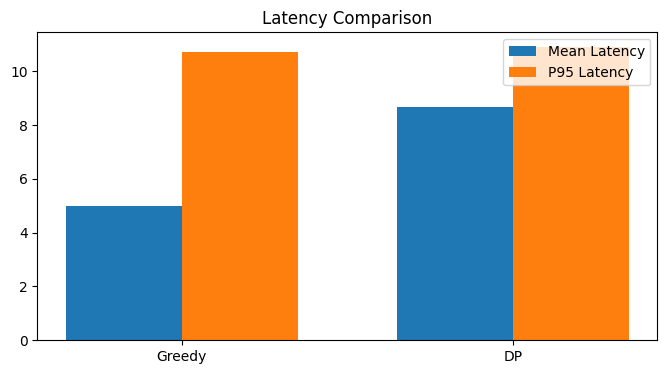

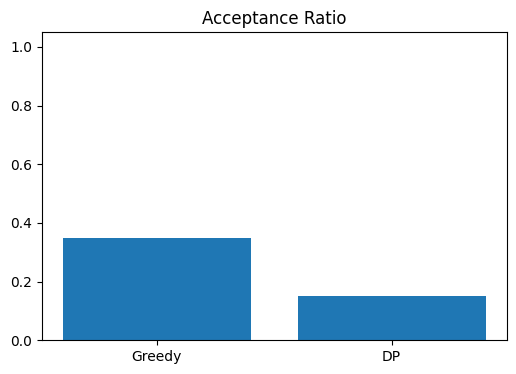

Saved outputs to /content/placement_outputs


In [41]:
# Demo end-to-end run
def demo_run():
    # restrict flows for speed
    demo_flows = flows[:20]
    # build candidate paths (already built for subset earlier; otherwise call ensure_candidate_paths)
    # run greedy
    placement_greedy = greedy_placer(G, demo_flows, sfc_map, vnfs, flow_path_candidates)
    metrics_greedy = evaluate_placement(G, demo_flows, placement_greedy, sfc_map, flow_path_candidates)
    print("Greedy metrics:", metrics_greedy)
    # run DP
    placement_dp, costs_dp = dp_placer_all(G, demo_flows, sfc_map, vnfs, flow_path_candidates)
    metrics_dp = evaluate_placement(G, demo_flows, placement_dp, sfc_map, flow_path_candidates)
    print("DP metrics:", metrics_dp)
    # run MILP on tiny subset (if pulp available)
    milp_metrics=None
    if PULP_AVAILABLE:
        try:
            milp_flows = demo_flows[:8]
            x_sol, z_sol, w_sol, y_sol, stats = build_and_solve_milp(G, milp_flows, {f.id:sfc_map[f.id] for f in milp_flows}, {f.id:flow_path_candidates[f.id] for f in milp_flows}, vnfs, time_limit_s=30)
            print("MILP stats:", stats)
            # reconstruct milp placement
            placement_milp={}
            for f in milp_flows:
                sfc = sfc_map[f.id]; assign={}
                for i,v in enumerate(sfc):
                    for n in G.nodes():
                        if z_sol.get((f.id,i,n),0)==1:
                            assign[i]=n
                placement_milp[f.id] = assign if assign else None
            milp_metrics = evaluate_placement(G, milp_flows, placement_milp, sfc_map, flow_path_candidates)
            print("MILP metrics (subset):", milp_metrics)
        except Exception as e:
            print("MILP failed:", e)
    # animate DP
    events = build_packet_event_list(G, demo_flows, placement_dp, sfc_map, flow_path_candidates, positions)
    anim_html = animate_packet_events(G, positions, events)
    display(anim_html)
    # comparison plots
    metrics_dict = {'Greedy':metrics_greedy, 'DP':metrics_dp}
    if milp_metrics: metrics_dict['MILP'] = milp_metrics
    # bar chart of mean/p95
    names=list(metrics_dict.keys())
    means=[metrics_dict[n]['mean_latency'] or 0 for n in names]
    p95=[metrics_dict[n]['p95_latency'] or 0 for n in names]
    x=np.arange(len(names)); width=0.35
    fig, ax = plt.subplots(figsize=(8,4))
    ax.bar(x-width/2, means, width, label='Mean Latency'); ax.bar(x+width/2, p95, width, label='P95 Latency')
    ax.set_xticks(x); ax.set_xticklabels(names); ax.legend(); ax.set_title('Latency Comparison'); plt.show()
    # acceptance ratio
    fig, ax = plt.subplots(figsize=(6,4))
    ratios=[metrics_dict[n]['accepted']/metrics_dict[n]['total'] if metrics_dict[n]['total']>0 else 0 for n in names]
    ax.bar(names, ratios); ax.set_ylim(0,1.05); ax.set_title('Acceptance Ratio'); plt.show()
    # save outputs
    out_dir='/content/placement_outputs'; os.makedirs(out_dir, exist_ok=True)
    with open(os.path.join(out_dir,'placements_dp.json'),'w') as f: json.dump(placement_dp, f, indent=2)
    with open(os.path.join(out_dir,'placements_greedy.json'),'w') as f: json.dump(placement_greedy, f, indent=2)
    with open(os.path.join(out_dir,'metrics.json'),'w') as f: json.dump(metrics_dict, f, indent=2)
    print("Saved outputs to", out_dir)
    return metrics_dict

# Run demo
results = demo_run()
